# Evaluation Pipeline — V6

Pipeline under evaluation:
```
Stage 1  → Groq LLM rewrites raw ticket                                     (call #1 — gated by confidence)
Stage 2a → Fine-tuned DistilBERT V6: dept + priority classification          (no API, always)
Stage 2b → Hybrid RAG: all-MiniLM-L6-v2 → FAISS+BM25+RRF+BGE reranker      (no API, gated)
Stage 3  → Groq LLM decides dept + priority from all 3 sources              (call #2 — gated)
```

| Section | What | API calls |
|---|---|---|
| 1 | Transformer standalone — accuracy, F1, calibration, ECE | None |
| 2 | RAG retrieval — Recall@K, MRR, CE distributions | None |
| 3 | Full pipeline — accuracy, LLM override rate, TTFT, TPOT | 2/ticket |
| 4 | AI-as-a-judge — rewrite quality, reasoning quality, routing quality | 3/ticket |

**Resume support:** every section caches results to `outputs/evaluation/`. Rerun any cell to resume.

**Token rotation:** add up to 6 keys in `secrets.env` as `GROQ_API_KEY`, `GROQ_API_KEY_2` ... `GROQ_API_KEY_6`.

In [1]:
import os, sys, time, json, re, warnings, pickle, math
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

OUT_DIR = os.path.join(ROOT, 'outputs', 'evaluation')
os.makedirs(OUT_DIR, exist_ok=True)

TRANSFORMER_RESULTS_PATH = os.path.join(OUT_DIR, 'transformer_results.csv')
RAG_RESULTS_PATH         = os.path.join(OUT_DIR, 'rag_retrieval_results.csv')
PIPELINE_RESULTS_PATH    = os.path.join(OUT_DIR, 'pipeline_results.csv')
JUDGE_RESULTS_PATH       = os.path.join(OUT_DIR, 'judge_results.csv')

from dotenv import load_dotenv
load_dotenv()
# load_dotenv(os.path.join(ROOT, 'secrets.env'))
HF_TOKEN = os.getenv('HF_TOKEN')

# ── Token rotation ─────────────────────────────────────────────────────
import groq as _groq_mod
from groq import Groq, RateLimitError

# _raw_tokens = [
#     os.getenv('GROQ_API_KEY',   ''),
#     os.getenv('GROQ_API_KEY_2', ''),
#     os.getenv('GROQ_API_KEY_3', ''),
#     os.getenv('GROQ_API_KEY_4', ''),
#     os.getenv('GROQ_API_KEY_5', ''),
#     os.getenv('GROQ_API_KEY_6', ''),
# ]
# GROQ_TOKENS = [t for t in _raw_tokens if t.startswith('gsk_')]
assert HF_TOKEN and HF_TOKEN.startswith('hf_'), 'HF_TOKEN missing'
# assert GROQ_TOKENS, 'No GROQ tokens found'

class TokenRotator:
    def __init__(self, tokens):
        self.tokens    = tokens
        self.idx       = 0
        self.client    = Groq(api_key=tokens[0])
        self.exhausted = False

    def call(self, model, messages, temperature=0.0, max_tokens=500):
        while self.idx < len(self.tokens):
            try:
                r = self.client.chat.completions.create(
                    model=model, messages=messages,
                    temperature=temperature, max_tokens=max_tokens)
                return r.choices[0].message.content.strip()
            except RateLimitError:
                self.idx += 1
                if self.idx < len(self.tokens):
                    print(f'  ⚠ Token exhausted — switching to token {self.idx+1}')
                    self.client = Groq(api_key=self.tokens[self.idx])
                else:
                    self.exhausted = True
                    print('  ✗ All tokens exhausted')
                    return None
            except Exception as e:
                print(f'  ⚠ API error: {e}')
                return None
        self.exhausted = True
        return None


class RotatingGroqClient:
    """
    Wraps TokenRotator so it looks like a Groq client to route_ticket,
    stage1_rewriter, and stage3_generator — which all call
    groq_client.chat.completions.create(...) internally.
    Rotation happens automatically on every 429.
    """
    def __init__(self, rotator):
        self.rotator     = rotator
        self.chat        = self
        self.completions = self

    def create(self, model, messages, temperature=0.0, max_tokens=500, **kwargs):
        while self.rotator.idx < len(self.rotator.tokens):
            try:
                return self.rotator.client.chat.completions.create(
                    model=model, messages=messages,
                    temperature=temperature, max_tokens=max_tokens
                )
            except RateLimitError:
                self.rotator.idx += 1
                if self.rotator.idx < len(self.rotator.tokens):
                    print(f'  ⚠ Token exhausted — switching to token {self.rotator.idx+1}')
                    self.rotator.client = Groq(api_key=self.rotator.tokens[self.rotator.idx])
                else:
                    self.rotator.exhausted = True
                    raise RateLimitError('All tokens exhausted')
        raise RateLimitError('All tokens exhausted')


# rotator     = TokenRotator(GROQ_TOKENS)
# groq_client = RotatingGroqClient(rotator)   # pipeline calls rotate automatically on 429

# print(f'{len(GROQ_TOKENS)} Groq token(s) loaded')
print(f'Outputs: {OUT_DIR}')

Outputs: /Users/avani/IdeaProjects/customer-support-management/outputs/evaluation


In [5]:
import torch
import pandas as pd
import numpy as np
import joblib
import faiss
from tqdm import tqdm
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

from pipeline.stage2a_transformer import MultiTaskModel, clean_text, transformer_predict
from pipeline.stage2b_retriever   import hybrid_retrieve, retrieve_priority_chunk
from pipeline.stage1_rewriter     import rewrite_query as _stage1
from pipeline.router               import route_ticket

TRANSFORMER_ID = 'Nethra19/multitask-ticket-model-v6'
RAG_REPO_ID    = 'Nethra19/rag-index-v6'
STAGE3_MODEL   = 'meta-llama/llama-4-scout-17b-16e-instruct'
JUDGE_MODEL    = 'meta-llama/llama-4-scout-17b-16e-instruct'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'mps'
print(f'Device: {device}')

print('Loading V6 transformer...')
tokenizer        = AutoTokenizer.from_pretrained(TRANSFORMER_ID, token=HF_TOKEN)
queue_encoder    = joblib.load(hf_hub_download(TRANSFORMER_ID, 'queue_encoder.pkl',    token=HF_TOKEN))
priority_encoder = joblib.load(hf_hub_download(TRANSFORMER_ID, 'priority_encoder.pkl', token=HF_TOKEN))
model = MultiTaskModel(TRANSFORMER_ID, len(queue_encoder.classes_), len(priority_encoder.classes_))
heads = torch.load(hf_hub_download(TRANSFORMER_ID, 'heads.pt', token=HF_TOKEN),
                   map_location=device, weights_only=False)
model.queue_classifier.load_state_dict(heads['queue_classifier'])
model.priority_classifier.load_state_dict(heads['priority_classifier'])
model.to(device).eval()
print('  Transformer ready')

print('Loading RAG artifacts...')
faiss_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_compliance_index.faiss', token=HF_TOKEN, repo_type='model'))
with open(hf_hub_download(RAG_REPO_ID, 'rag_bm25_index.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    bm25 = pickle.load(f)['bm25']
with open(hf_hub_download(RAG_REPO_ID, 'rag_compliance_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    all_chunks = pickle.load(f)
priority_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_priority_index.faiss', token=HF_TOKEN, repo_type='model'))
with open(hf_hub_download(RAG_REPO_ID, 'rag_priority_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    priority_chunks = pickle.load(f)
embedder      = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('BAAI/bge-reranker-base')
print(f'  RAG ready: {faiss_index.ntotal} dept vectors')
print('\n✓ All components ready')

Device: mps
Loading V6 transformer...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 16000.24it/s]


  Transformer ready
Loading RAG artifacts...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9862.19it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9577.34it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  RAG ready: 72 dept vectors

✓ All components ready


In [6]:
test_df = pd.read_csv('./outputs/test_clean.csv')
# text column is already body-only, cleaned
test_df['raw_text'] = test_df['text'].fillna('').str.strip()

print(f'Test set: {len(test_df)} tickets')
print(test_df['queue'].value_counts())

# 30 per dept for Sections 1+2 — no API cost
eval_df = pd.concat([
    group.sample(min(len(group), 30), random_state=42)
    for _, group in test_df.groupby('queue')
]).reset_index(drop=True)

# 10 per dept for Sections 3+4 — Groq calls
pipeline_df = pd.concat([
    group.sample(min(len(group), 24), random_state=42)
    for _, group in test_df.groupby('queue')
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nEval sample (Sec 1+2): {len(eval_df)} | Pipeline sample (Sec 3+4): {len(pipeline_df)}')

Test set: 192 tickets
queue
Billing and Payments               24
Customer Service                   24
General Inquiry                    24
Human Resources                    24
Returns and Exchanges              24
Sales and Pre-Sales                24
Service Outages and Maintenance    24
Technical & IT Support             24
Name: count, dtype: int64

Eval sample (Sec 1+2): 192 | Pipeline sample (Sec 3+4): 192


---
## Section 1 — Transformer Standalone (Stage 2a)
No API calls. DistilBERT V6 classifier in isolation — baseline before RAG or LLM.

In [7]:
if os.path.exists(TRANSFORMER_RESULTS_PATH):
    trans_df = pd.read_csv(TRANSFORMER_RESULTS_PATH)
    print(f'Loaded cached transformer results ({len(trans_df)} rows)')
else:
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        r = transformer_predict(
            row['raw_text'], model, tokenizer, queue_encoder, priority_encoder, device
        )
        records.append({
            'true_dept'    : row['queue'],    'true_priority': row['priority'],
            'pred_dept'    : r['dept'],        'dept_conf'    : r['dept_conf'],
            'pred_priority': r['priority'],    'priority_conf': r['priority_conf'],
        })
    trans_df = pd.DataFrame(records)
    trans_df.to_csv(TRANSFORMER_RESULTS_PATH, index=False)
    print(f'Saved {len(trans_df)} rows')

  0%|          | 0/192 [00:00<?, ?it/s]

18:39:09  DEBUG     [stage2a.transformer]  Predicting on (226 chars): 'We noticed a discrepancy on our March invoice. The total shows $7,250 but our expected amount based '...
18:39:10  INFO      [stage2a.transformer]  Stage 2a — dept=Billing and Payments (99.4%)  priority=medium (87.0%)
18:39:10  DEBUG     [stage2a.transformer]  Top-3: [('Billing and Payments', 0.9935), ('Returns and Exchanges', 0.0022), ('Service Outages and Maintenance', 0.0021)]


  1%|          | 1/192 [00:00<00:42,  4.47it/s]

18:39:10  DEBUG     [stage2a.transformer]  Predicting on (232 chars): 'Could you provide information about the payment methods you currently accept for enterprise subscrip'...
18:39:10  INFO      [stage2a.transformer]  Stage 2a — dept=Billing and Payments (97.1%)  priority=medium (93.0%)
18:39:10  DEBUG     [stage2a.transformer]  Top-3: [('Billing and Payments', 0.9708), ('Returns and Exchanges', 0.0139), ('Sales and Pre-Sales', 0.0093)]
18:39:10  DEBUG     [stage2a.transformer]  Predicting on (244 chars): 'Our account was charged twice for the annual SaaS subscription renewal last week. The duplicate tran'...
18:39:10  INFO      [stage2a.transformer]  Stage 2a — dept=Billing and Payments (93.8%)  priority=medium (95.5%)
18:39:10  DEBUG     [stage2a.transformer]  Top-3: [('Billing and Payments', 0.9384), ('Returns and Exchanges', 0.0391), ('Service Outages and Maintenance', 0.0062)]
18:39:10  DEBUG     [stage2a.transformer]  Predicting on (216 chars): 'Following the resolution of our b

  2%|▏         | 4/192 [00:00<00:14, 13.01it/s]

...

18:39:13  DEBUG     [stage2a.transformer]  Predicting on (259 chars): 'Our CI/CD pipeline has been experiencing elevated build failure rates since the Jenkins server was p'...
18:39:13  INFO      [stage2a.transformer]  Stage 2a — dept=Technical & IT Support (67.8%)  priority=medium (75.5%)
18:39:13  DEBUG     [stage2a.transformer]  Top-3: [('Technical & IT Support', 0.6776), ('Human Resources', 0.0783), ('Sales and Pre-Sales', 0.0773)]
18:39:13  DEBUG     [stage2a.transformer]  Predicting on (249 chars): 'Since the authentication system update at 2 AM, no users across the organization can log into any cl'...
18:39:13  INFO      [stage2a.transformer]  Stage 2a — dept=Human Resources (97.0%)  priority=high (83.3%)
18:39:13  DEBUG     [stage2a.transformer]  Top-3: [('Human Resources', 0.9703), ('Sales and Pre-Sales', 0.0078), ('Service Outages and Maintenance', 0.0053)]
18:39:13  DEBUG     [stage2a.transformer]  Predicting on (227 chars): 'I would like to know the recommended approach for

 96%|█████████▌| 184/192 [00:03<00:00, 82.68it/s]

18:39:13  DEBUG     [stage2a.transformer]  Predicting on (245 chars): 'I encountered a minor issue transferring medical imaging data from a USB 3.0 device to our workstati'...
18:39:13  INFO      [stage2a.transformer]  Stage 2a — dept=Human Resources (81.6%)  priority=medium (84.6%)
18:39:13  DEBUG     [stage2a.transformer]  Top-3: [('Human Resources', 0.8158), ('General Inquiry', 0.0973), ('Technical & IT Support', 0.0304)]
18:39:13  DEBUG     [stage2a.transformer]  Predicting on (219 chars): 'Could you provide guidance on configuring log rotation for our application servers? The current setu'...
18:39:13  INFO      [stage2a.transformer]  Stage 2a — dept=Technical & IT Support (43.0%)  priority=medium (87.1%)
18:39:13  DEBUG     [stage2a.transformer]  Top-3: [('Technical & IT Support', 0.4298), ('Human Resources', 0.416), ('General Inquiry', 0.045)]
18:39:13  DEBUG     [stage2a.transformer]  Predicting on (226 chars): 'Could you share documentation on your recommended laptop hardware 

100%|██████████| 192/192 [00:03<00:00, 55.40it/s]

Saved 192 rows


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

dept_acc = accuracy_score(trans_df['true_dept'],     trans_df['pred_dept'])
dept_f1  = f1_score(trans_df['true_dept'],     trans_df['pred_dept'],     average='macro', zero_division=0)
prio_acc = accuracy_score(trans_df['true_priority'], trans_df['pred_priority'])
prio_f1  = f1_score(trans_df['true_priority'], trans_df['pred_priority'], average='macro', zero_division=0)

print('=' * 55)
print('TRANSFORMER STANDALONE (V6)')
print('=' * 55)
print(f'Dept  Accuracy: {dept_acc*100:.1f}%  Macro F1: {dept_f1*100:.1f}%')
print(f'Prio  Accuracy: {prio_acc*100:.1f}%  Macro F1: {prio_f1*100:.1f}%')
print()
print('DEPARTMENT REPORT:')
print(classification_report(trans_df['true_dept'], trans_df['pred_dept'], zero_division=0))
print('PRIORITY REPORT:')
print(classification_report(trans_df['true_priority'], trans_df['pred_priority'], zero_division=0))

TRANSFORMER STANDALONE (V6)
Dept  Accuracy: 48.4%  Macro F1: 42.0%
Prio  Accuracy: 40.6%  Macro F1: 29.9%

DEPARTMENT REPORT:
                                 precision    recall  f1-score   support

           Billing and Payments       0.88      0.96      0.92        24
               Customer Service       0.50      0.04      0.08        24
                General Inquiry       0.12      0.04      0.06        24
                Human Resources       0.42      1.00      0.59        24
          Returns and Exchanges       0.38      0.46      0.42        24
            Sales and Pre-Sales       0.43      0.75      0.55        24
Service Outages and Maintenance       0.55      0.46      0.50        24
         Technical & IT Support       0.50      0.17      0.25        24

                       accuracy                           0.48       192
                      macro avg       0.47      0.48      0.42       192
                   weighted avg       0.47      0.48      0.42       

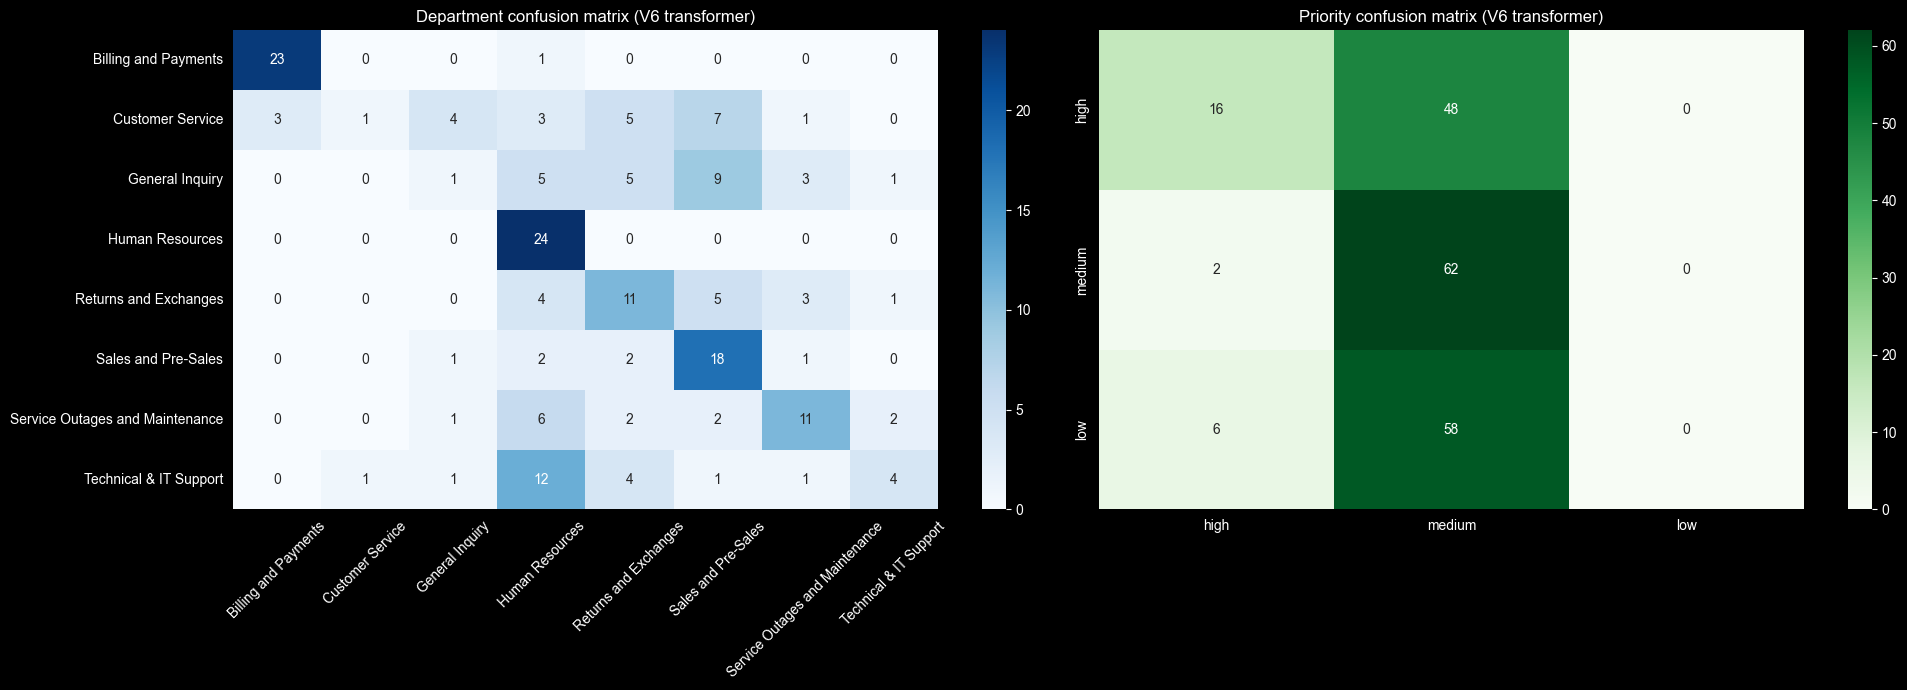

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
dept_labels = sorted(trans_df['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

sns.heatmap(confusion_matrix(trans_df['true_dept'], trans_df['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0])
axes[0].set_title('Department confusion matrix (V6 transformer)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(trans_df['true_priority'], trans_df['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens',
    xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1])
axes[1].set_title('Priority confusion matrix (V6 transformer)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'transformer_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

Department ECE: 0.2276  |  Priority ECE: 0.4193  (lower = better calibrated)


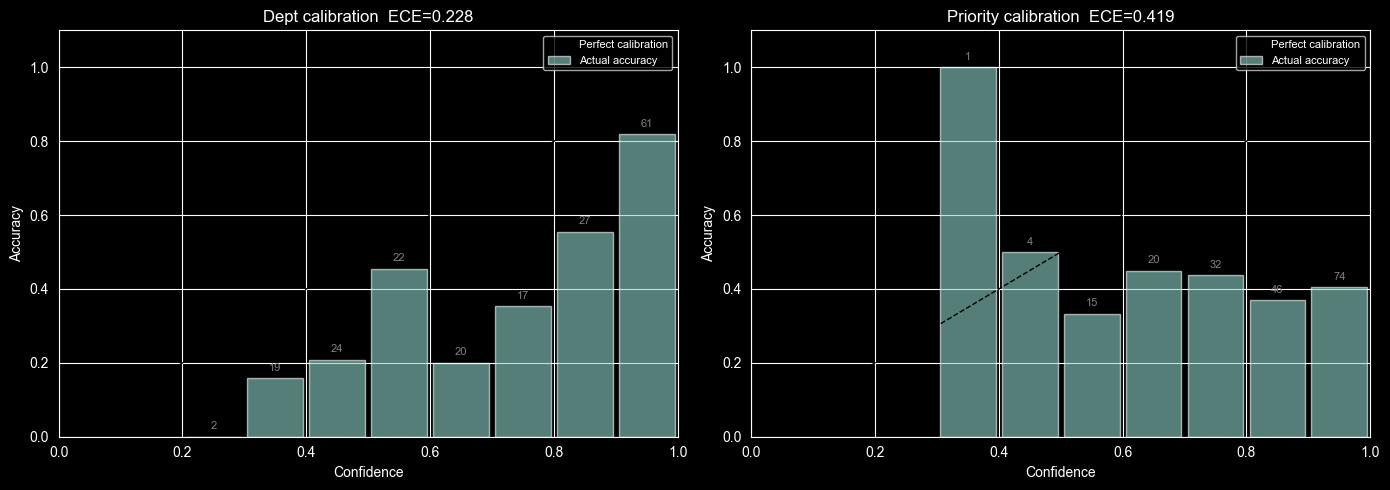

In [10]:
# Confidence calibration + ECE
def calibration_data(df, conf_col, correct_col, n=10):
    bins = np.linspace(0, 1, n + 1)
    mids, accs, counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = df[(df[conf_col] >= lo) & (df[conf_col] < hi)]
        if len(s) == 0: continue
        mids.append((lo+hi)/2); accs.append(s[correct_col].mean()); counts.append(len(s))
    return np.array(mids), np.array(accs), np.array(counts)

def ece(mids, accs, counts):
    return float(np.sum(counts * np.abs(mids - accs)) / counts.sum())

trans_df['dept_correct'] = (trans_df['pred_dept']     == trans_df['true_dept']).astype(int)
trans_df['prio_correct'] = (trans_df['pred_priority'] == trans_df['true_priority']).astype(int)

d_m, d_a, d_c = calibration_data(trans_df, 'dept_conf',     'dept_correct')
p_m, p_a, p_c = calibration_data(trans_df, 'priority_conf', 'prio_correct')
dept_ece = ece(d_m, d_a, d_c)
prio_ece = ece(p_m, p_a, p_c)
print(f'Department ECE: {dept_ece:.4f}  |  Priority ECE: {prio_ece:.4f}  (lower = better calibrated)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mids, accs, counts, ece_val, title in [
    (axes[0], d_m, d_a, d_c, dept_ece, f'Dept calibration  ECE={dept_ece:.3f}'),
    (axes[1], p_m, p_a, p_c, prio_ece, f'Priority calibration  ECE={prio_ece:.3f}'),
]:
    w = mids[1]-mids[0] if len(mids)>1 else 0.1
    ax.bar(mids, accs, width=w*0.9, alpha=0.6, label='Actual accuracy')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
    for m,a,c in zip(mids,accs,counts): ax.text(m,a+0.02,str(c),ha='center',fontsize=8,color='grey')
    ax.set_xlim(0,1); ax.set_ylim(0,1.1)
    ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — RAG Retrieval (Stage 2b)
No API calls. Uses `all-MiniLM-L6-v2` embedder + BGE reranker (V6 — fixes domain mismatch).
Evaluates whether the correct dept chunk and priority chunk are retrieved.

In [11]:
def tokenize_bm25(text):
    return re.sub(r'[^\w\s]', ' ', text.lower()).split()


def retrieve_dept(query, top_n=4):
    """Identical retrieval logic to stage2b_retriever.hybrid_retrieve."""
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    _, dense_ids = faiss_index.search(q_emb, 10)
    dense_ids    = dense_ids[0].tolist()

    bm25_scores = bm25.get_scores(tokenize_bm25(query))
    bm25_ids    = np.argsort(bm25_scores)[::-1][:10].tolist()

    rrf = {}
    for rank, idx in enumerate(dense_ids):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)
    for rank, idx in enumerate(bm25_ids):
        rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)

    candidate_ids = [i for i, _ in sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:20]]
    raw_scores    = cross_encoder.predict([[query, all_chunks[i]['text']] for i in candidate_ids])
    ce_scores     = [1 / (1 + math.exp(-s)) for s in raw_scores]  # sigmoid — BGE outputs raw logits
    ranked        = sorted(zip(candidate_ids, ce_scores), key=lambda x: x[1], reverse=True)

    return [
        {'chunk': all_chunks[idx], 'ce_score': float(score)}
        for idx, score in ranked[:top_n]
    ]


def retrieve_priority(query):
    q_emb = embedder.encode([query], normalize_embeddings=True).astype('float32')
    k     = min(len(priority_chunks), 3)
    _, ids = priority_index.search(q_emb, k)
    cand   = ids[0].tolist()
    raw    = cross_encoder.predict([[query, priority_chunks[i]['text']] for i in cand])
    ce     = [1 / (1 + math.exp(-s)) for s in raw]
    best   = int(np.argmax(ce))
    return {'chunk': priority_chunks[cand[best]], 'ce_score': float(ce[best])}


if os.path.exists(RAG_RESULTS_PATH):
    rag_df = pd.read_csv(RAG_RESULTS_PATH)
    print(f'Loaded cached RAG results ({len(rag_df)} rows)')
else:
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        query     = row['raw_text']
        true_dept = row['queue']
        true_prio = row['priority'].lower()

        chunks = retrieve_dept(query, top_n=4)
        depts  = [c['chunk']['dept'] for c in chunks]
        scores = [c['ce_score']      for c in chunks]
        r1     = int(depts[0] == true_dept) if depts else 0
        r4     = int(true_dept in depts)
        mrr    = next((1.0/(r+1) for r,d in enumerate(depts) if d==true_dept), 0.0)

        pc        = retrieve_priority(query)
        prio_sect = pc['chunk']['section'].lower()
        prio_ce   = pc['ce_score']

        records.append({
            'true_dept'    : true_dept,   'true_priority': true_prio,
            'top1_dept'    : depts[0] if depts else '',
            'recall_at_1'  : r1,          'recall_at_4'  : r4,
            'mrr'          : mrr,          'top_ce_score' : scores[0] if scores else 0.0,
            'prio_section' : prio_sect,    'prio_ce_score': prio_ce,
            'prio_correct' : int(prio_sect == true_prio),
        })

    rag_df = pd.DataFrame(records)
    rag_df.to_csv(RAG_RESULTS_PATH, index=False)
    print(f'Saved {len(rag_df)} rows')

100%|██████████| 192/192 [02:17<00:00,  1.39it/s]

Saved 192 rows


In [12]:
print('=' * 55)
print('RAG RETRIEVAL RESULTS (V6 — all-MiniLM + BGE reranker)')
print('=' * 55)
print(f'Dept  Recall@1 : {rag_df["recall_at_1"].mean()*100:.1f}%')
print(f'Dept  Recall@4 : {rag_df["recall_at_4"].mean()*100:.1f}%')
print(f'Dept  MRR      : {rag_df["mrr"].mean():.3f}')
print(f'Prio  Section  : {rag_df["prio_correct"].mean()*100:.1f}%  (random baseline 33.3%)')
print()
print('Recall@1 per department:')
per_dept = rag_df.groupby('true_dept')['recall_at_1'].agg(['mean','count']).rename(
    columns={'mean':'Recall@1','count':'N'}).sort_values('Recall@1', ascending=False)
per_dept['Recall@1'] = (per_dept['Recall@1']*100).round(1).astype(str)+'%'
print(per_dept)

print(f'\nCE score distribution (after sigmoid):')
print(f'  Mean top CE   : {rag_df["top_ce_score"].mean():.3f}')
print(f'  Median top CE : {rag_df["top_ce_score"].median():.3f}')
print(f'  Min / Max     : {rag_df["top_ce_score"].min():.3f} / {rag_df["top_ce_score"].max():.3f}')

RAG RETRIEVAL RESULTS (V6 — all-MiniLM + BGE reranker)
Dept  Recall@1 : 58.9%
Dept  Recall@4 : 87.5%
Dept  MRR      : 0.703
Prio  Section  : 58.3%  (random baseline 33.3%)

Recall@1 per department:
                                Recall@1   N
true_dept                                   
Billing and Payments               83.3%  24
General Inquiry                    79.2%  24
Human Resources                    66.7%  24
Service Outages and Maintenance    62.5%  24
Sales and Pre-Sales                58.3%  24
Customer Service                   50.0%  24
Technical & IT Support             37.5%  24
Returns and Exchanges              33.3%  24

CE score distribution (after sigmoid):
  Mean top CE   : 0.524
  Median top CE : 0.503
  Min / Max     : 0.500 / 0.729


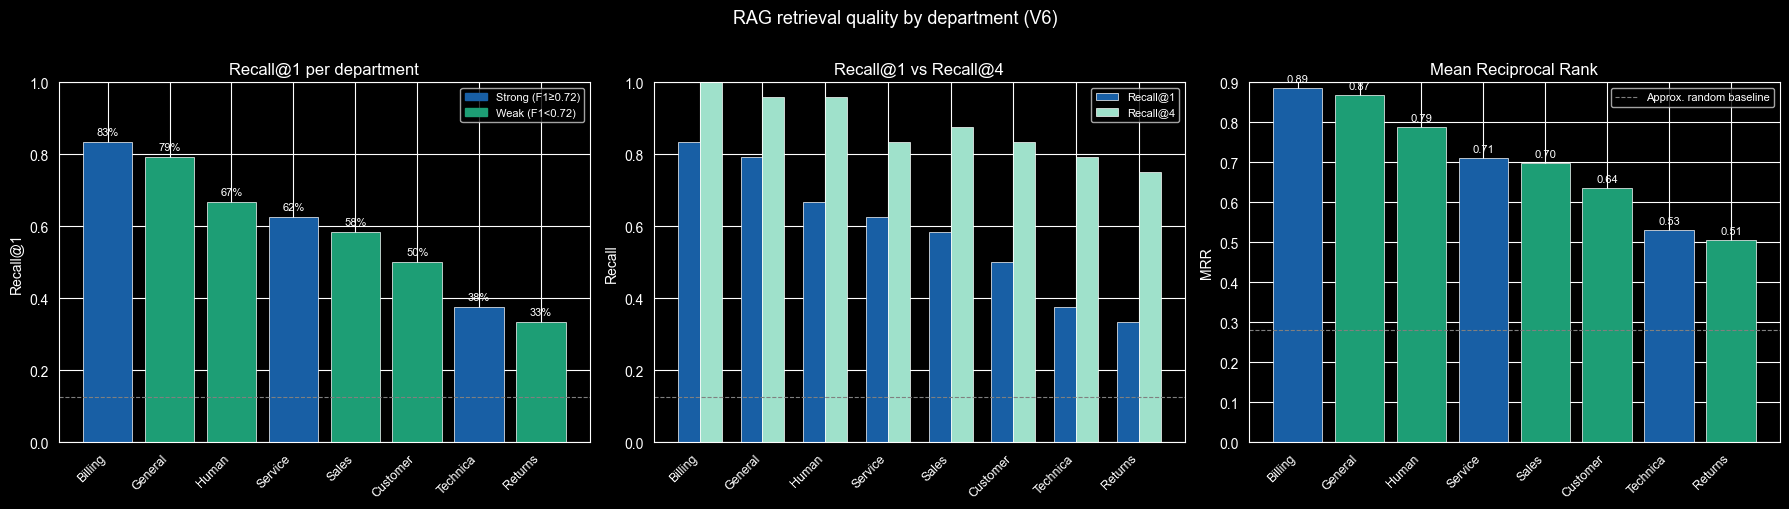

In [13]:
import matplotlib.patches as mpatches

depts_sorted = rag_df.groupby('true_dept')['recall_at_1'].mean().sort_values(ascending=False).index.tolist()
short = [d.replace(' and ', '\n').replace(' & ', '\n').split()[0][:8] for d in depts_sorted]

# V6 F1 scores from training eval — used to colour weak vs strong classes
DEPT_F1 = {
    'Billing and Payments':            0.99,
    'Customer Service':                0.60,
    'General Inquiry':                 0.64,
    'Human Resources':                 0.65,
    'Returns and Exchanges':           0.68,
    'Sales and Pre-Sales':             0.71,
    'Service Outages and Maintenance': 0.76,
    'Technical & IT Support':          0.78,
}
is_weak = [DEPT_F1.get(d, 1.0) < 0.72 for d in depts_sorted]
colors  = ['#1D9E75' if w else '#185FA5' for w in is_weak]

r1_  = rag_df.groupby('true_dept')['recall_at_1'].mean().reindex(depts_sorted).values
r4_  = rag_df.groupby('true_dept')['recall_at_4'].mean().reindex(depts_sorted).values
mrr_ = rag_df.groupby('true_dept')['mrr'].mean().reindex(depts_sorted).values
x, w = np.arange(len(depts_sorted)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RAG retrieval quality by department (V6)', fontsize=13, y=1.01)

bars = axes[0].bar(x, r1_, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[0].set_ylim(0,1); axes[0].set_ylabel('Recall@1'); axes[0].set_title('Recall@1 per department')
for b,v in zip(bars,r1_): axes[0].text(b.get_x()+b.get_width()/2,v+0.02,f'{v*100:.0f}%',ha='center',fontsize=8)
axes[0].legend(handles=[mpatches.Patch(color='#185FA5',label='Strong (F1≥0.72)'),
                         mpatches.Patch(color='#1D9E75',label='Weak (F1<0.72)')],fontsize=8)

axes[1].bar(x-w/2, r1_, w, label='Recall@1', color='#185FA5', edgecolor='white', linewidth=0.5)
axes[1].bar(x+w/2, r4_, w, label='Recall@4', color='#9FE1CB', edgecolor='white', linewidth=0.5)
axes[1].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[1].set_ylim(0,1); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall@1 vs Recall@4'); axes[1].legend(fontsize=8)

bars3 = axes[2].bar(x, mrr_, color=colors, edgecolor='white', linewidth=0.5)
axes[2].axhline(0.28, color='grey', linestyle='--', lw=0.8, label='Approx. random baseline')
axes[2].set_xticks(x); axes[2].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[2].set_ylim(0,0.9); axes[2].set_ylabel('MRR')
axes[2].set_title('Mean Reciprocal Rank'); axes[2].legend(fontsize=8)
for b,v in zip(bars3,mrr_): axes[2].text(b.get_x()+b.get_width()/2,v+0.015,f'{v:.2f}',ha='center',fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'rag_retrieval_by_dept.png'),dpi=150,bbox_inches='tight')
plt.show()

---
## Section 3 — Full Pipeline: Accuracy + Latency

**Stage 1** always runs (Groq rewrite). **Stage 3 LLM** only runs when transformer confidence is below per-class threshold — otherwise fast path.

**TTFT** = Stage 1 latency — the first blocking LLM call.

**TPOT** = Stage 3 estimated latency / output tokens. Stage 3 generates a reasoning paragraph — TPOT varies with ticket complexity.

In [14]:
print('Measuring TTFT baseline (Stage 1 warm-up)...')
_t0 = time.perf_counter()
_ = _stage1(pipeline_df.iloc[0]['raw_text'])
TTFT_BASELINE = round(time.perf_counter() - _t0, 3)
print(f'TTFT baseline: {TTFT_BASELINE:.3f}s')
time.sleep(2.0)

# Per-class thresholds (V6)
DEPT_THRESHOLDS = {
    'Billing and Payments':            0.85,
    'Customer Service':                0.85,
    'General Inquiry':                 0.85,
    'Human Resources':                 0.85,
    'Returns and Exchanges':           0.85,
    'Sales and Pre-Sales':             0.85,
    'Service Outages and Maintenance': 0.85,
    'Technical & IT Support':          0.85,
}
PRIORITY_THRESHOLD = 0.75
print(len(pipeline_df))

Measuring TTFT baseline (Stage 1 warm-up)...
18:42:32  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (227 chars)
18:42:32  DEBUG     [stage1.rewriter]  Raw input: 'Our account manager left your company recently and we have not been assigned a new one. We have several pending requests'
18:42:34  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Request for new account manager assignment'
18:42:34  DEBUG     [stage1.rewriter]  Urgency signals : ['pending requests', 'upcoming renewal discussion', 'needs attention']
18:42:34  DEBUG     [stage1.rewriter]  Tech keywords   : []
18:42:34  DEBUG     [stage1.rewriter]  Explanation     : The likely department is account management.
18:42:34  DEBUG     [stage1.rewriter]  Cleaned text: 'Our account manager left your company recently, and we have not been assigned a new one. We have several pending request'
TTFT baseline: 2.048s
192


In [15]:


if os.path.exists(PIPELINE_RESULTS_PATH):
    _ex = pd.read_csv(PIPELINE_RESULTS_PATH)
    if len(_ex) > 0 and 'pred_dept' in _ex.columns:
        results_df = _ex
        print(f'Loaded cached pipeline results ({len(results_df)} rows)')
    else:
        os.remove(PIPELINE_RESULTS_PATH)

if not os.path.exists(PIPELINE_RESULTS_PATH):
    records, errors = [], 0
    for idx, row in tqdm(pipeline_df.iterrows(), total=len(pipeline_df)):
        try:
            t0  = time.perf_counter()
            res = route_ticket(
                row['raw_text'],
                model, tokenizer, queue_encoder, priority_encoder, device,
                embedder,
                faiss_index, bm25, all_chunks, cross_encoder,
                priority_index, priority_chunks
            )
            t_total          = round(time.perf_counter() - t0, 3)
            reasoning_tokens = max(len(res.reasoning.split()), 1)
            t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
            dept_thr         = DEPT_THRESHOLDS.get(res.transformer_dept, 0.70)
            fast_path        = (res.transformer_conf >= dept_thr and
                                res.priority_probs.get(res.priority, 0) >= PRIORITY_THRESHOLD)
            records.append({
                'true_dept'         : row['queue'],
                'true_priority'     : row['priority'],
                'pred_dept'         : res.department,
                'pred_priority'     : res.priority,
                'transformer_dept'  : res.transformer_dept,
                'transformer_conf'  : res.transformer_conf,
                'confidence'        : res.confidence,
                'llm_overrides_dept': int(res.department != res.transformer_dept),
                'fast_path'         : int(fast_path),
                't_total_s'         : t_total,
                'ttft_s'            : TTFT_BASELINE,
                'tpot_s'            : round(t_stage3_est / reasoning_tokens, 4),
                'reasoning_tokens'  : reasoning_tokens,
            })
        except Exception as e:
            if '429' in str(e) or 'rate_limit' in str(e).lower():
                pd.DataFrame(records).to_csv(PIPELINE_RESULTS_PATH, index=False)
                wait = 60
                print(f'\n⚠ Rate limit at row {idx} — waiting {wait}s then retrying...')
                time.sleep(wait)
                try:
                    t0  = time.perf_counter()
                    res = route_ticket(
                        row['raw_text'],
                        model, tokenizer, queue_encoder, priority_encoder, device,
                        embedder,
                        faiss_index, bm25, all_chunks, cross_encoder,
                        priority_index, priority_chunks
                    )
                    t_total          = round(time.perf_counter() - t0, 3)
                    reasoning_tokens = max(len(res.reasoning.split()), 1)
                    t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
                    dept_thr         = DEPT_THRESHOLDS.get(res.transformer_dept, 0.70)
                    fast_path        = (res.transformer_conf >= dept_thr and
                                        res.priority_probs.get(res.priority, 0) >= PRIORITY_THRESHOLD)
                    records.append({
                        'true_dept': row['queue'], 'true_priority': row['priority'],
                        'pred_dept': res.department, 'pred_priority': res.priority,
                        'transformer_dept': res.transformer_dept, 'transformer_conf': res.transformer_conf,
                        'confidence': res.confidence, 'llm_overrides_dept': int(res.department != res.transformer_dept),
                        'fast_path': int(fast_path), 't_total_s': t_total, 'ttft_s': TTFT_BASELINE,
                        'tpot_s': round(t_stage3_est/reasoning_tokens, 4), 'reasoning_tokens': reasoning_tokens,
                    })
                except Exception as e2:
                    errors += 1
                    print(f'✗ Retry failed for row {idx}: {e2}')
                    records.append({'true_dept': row['queue'], 'true_priority': row['priority'],
                                    'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                                    'transformer_dept': '', 'transformer_conf': 0.0,
                                    'confidence': 'low', 'llm_overrides_dept': 0, 'fast_path': 0,
                                    't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0})
            else:
                errors += 1
                print(f'✗ Row {idx}: {e}')
                records.append({'true_dept': row['queue'], 'true_priority': row['priority'],
                                'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                                'transformer_dept': '', 'transformer_conf': 0.0,
                                'confidence': 'low', 'llm_overrides_dept': 0, 'fast_path': 0,
                                't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0})
        time.sleep(1.5)

    results_df = pd.DataFrame(records)
    results_df.to_csv(PIPELINE_RESULTS_PATH, index=False)
    print(f'Saved {len(results_df)} tickets ({errors} errors)')

if 'results_df' not in dir():
    results_df = pd.read_csv(PIPELINE_RESULTS_PATH)

  0%|          | 0/192 [00:00<?, ?it/s]

18:42:44  INFO      [router]  ============================================================
18:42:44  INFO      [router]  NEW TICKET (227 chars): 'Our account manager left your company recently and we have not been assigned a n'
18:42:44  INFO      [router]  ============================================================
18:42:44  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (227 chars)
18:42:44  DEBUG     [stage1.rewriter]  Raw input: 'Our account manager left your company recently and we have not been assigned a new one. We have several pending requests'
18:42:47  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Request for new account manager assignment'
18:42:47  DEBUG     [stage1.rewriter]  Urgency signals : ['pending requests', 'upcoming renewal discussion', 'needs attention']
18:42:47  DEBUG     [stage1.rewriter]  Tech keywords   : []
18:42:47  DEBUG     [stage1.rewriter]  Explanation     : The likely department is account management.
18:42:47  DEBUG     [stage1.rewr

  1%|          | 1/192 [00:08<27:16,  8.57s/it]

18:42:53  INFO      [router]  ============================================================
18:42:53  INFO      [router]  NEW TICKET (252 chars): 'I noticed some product feature descriptions in your sales collateral reference c'
18:42:53  INFO      [router]  ============================================================
18:42:53  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (252 chars)
18:42:53  DEBUG     [stage1.rewriter]  Raw input: 'I noticed some product feature descriptions in your sales collateral reference capabilities from a previous version. The'
18:42:55  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Outdated product feature descriptions in sales collateral'
18:42:55  DEBUG     [stage1.rewriter]  Urgency signals : []
18:42:55  DEBUG     [stage1.rewriter]  Tech keywords   : ['cybersecurity module', 'data sheet', 'legacy firewall interface', 'cloud console']
18:42:55  DEBUG     [stage1.rewriter]  Explanation     : The likely department is marketing or product ma

  1%|          | 2/192 [00:11<17:14,  5.44s/it]

...

18:56:53  INFO      [router]  ============================================================
18:56:53  INFO      [router]  NEW TICKET (245 chars): 'The automated backup job for our PostgreSQL database has been failing intermitte'
18:56:53  INFO      [router]  ============================================================
18:56:53  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (245 chars)
18:56:53  DEBUG     [stage1.rewriter]  Raw input: 'The automated backup job for our PostgreSQL database has been failing intermittently over the past week. Approximately t'
18:56:54  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Intermittent failures in PostgreSQL backup job'
18:56:54  DEBUG     [stage1.rewriter]  Urgency signals : ['failing', 'errors']
18:56:54  DEBUG     [stage1.rewriter]  Tech keywords   : ['automated backup job', 'PostgreSQL database', 'nightly backups', 'log files', 'connection timeout', 'storage backend']
18:56:54  DEBUG     [stage1.rewriter]  Explanation     : The 

 99%|█████████▉| 191/192 [14:13<00:04,  4.59s/it]

18:56:58  INFO      [router]  ============================================================
18:56:58  INFO      [router]  NEW TICKET (250 chars): 'Our project management SaaS has encountered data synchronization failures across'
18:56:58  INFO      [router]  ============================================================
18:56:58  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (250 chars)
18:56:58  DEBUG     [stage1.rewriter]  Raw input: 'Our project management SaaS has encountered data synchronization failures across Jira and Confluence integrations, likel'
18:57:00  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Data synchronization failures in Jira and Confluence'
18:57:00  DEBUG     [stage1.rewriter]  Urgency signals : ['failures', 'affected', 'workaround']
18:57:00  DEBUG     [stage1.rewriter]  Tech keywords   : ['project management SaaS', 'data synchronization', 'Jira', 'Confluence', 'integrations', 'configuration errors', 'connector', 'workflow', 'manual data entry']

100%|██████████| 192/192 [14:19<00:00,  4.48s/it]

Saved 192 tickets (0 errors)


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

clean = results_df[results_df['pred_dept'] != 'ERROR'].copy()
clean['dept_correct']  = (clean['pred_dept']       == clean['true_dept']).astype(int)
clean['prio_correct']  = (clean['pred_priority']   == clean['true_priority']).astype(int)
clean['trans_correct'] = (clean['transformer_dept'] == clean['true_dept']).astype(int)

print('=' * 60)
print('FULL PIPELINE END-TO-END (V6)')
print('=' * 60)
print(f'Department Accuracy : {clean["dept_correct"].mean()*100:.1f}%')
print(f'Priority   Accuracy : {clean["prio_correct"].mean()*100:.1f}%')
print(f'Total tickets       : {len(clean)}')
print(f'Fast path tickets   : {clean["fast_path"].sum()} ({clean["fast_path"].mean()*100:.1f}%)')
print()

overrides  = clean[clean['llm_overrides_dept'] == 1]
agreements = clean[clean['llm_overrides_dept'] == 0]
print(f'LLM agreed with transformer : {len(agreements)} tickets')
print(f'  Dept accuracy             : {agreements["dept_correct"].mean()*100:.1f}%')
print()
print(f'LLM overrode transformer    : {len(overrides)} tickets ({len(overrides)/max(len(clean),1)*100:.1f}%)')
if len(overrides) > 0:
    trans_on_ov = overrides['trans_correct'].mean()
    llm_on_ov   = overrides['dept_correct'].mean()
    delta       = (llm_on_ov - trans_on_ov) * 100
    print(f'  Transformer accuracy on overridden tickets : {trans_on_ov*100:.1f}%')
    print(f'  LLM final accuracy on overridden tickets   : {llm_on_ov*100:.1f}%')
    print(f'  LLM override improvement                   : {delta:+.1f}pp')
    print(f'  (positive = LLM corrected transformer mistakes)')

print()
print('DEPARTMENT CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_dept'], clean['pred_dept'], zero_division=0))
print('PRIORITY CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_priority'], clean['pred_priority'], zero_division=0))

FULL PIPELINE END-TO-END (V6)
Department Accuracy : 59.9%
Priority   Accuracy : 54.2%
Total tickets       : 192
Fast path tickets   : 44 (22.9%)

LLM agreed with transformer : 120 tickets
  Dept accuracy             : 67.5%

LLM overrode transformer    : 72 tickets (37.5%)
  Transformer accuracy on overridden tickets : 13.9%
  LLM final accuracy on overridden tickets   : 47.2%
  LLM override improvement                   : +33.3pp
  (positive = LLM corrected transformer mistakes)

DEPARTMENT CLASSIFICATION REPORT (full pipeline):
                                 precision    recall  f1-score   support

           Billing and Payments       1.00      1.00      1.00        24
               Customer Service       1.00      0.12      0.22        24
                General Inquiry       0.47      0.33      0.39        24
                Human Resources       0.63      1.00      0.77        24
          Returns and Exchanges       0.80      0.33      0.47        24
            Sales and Pre

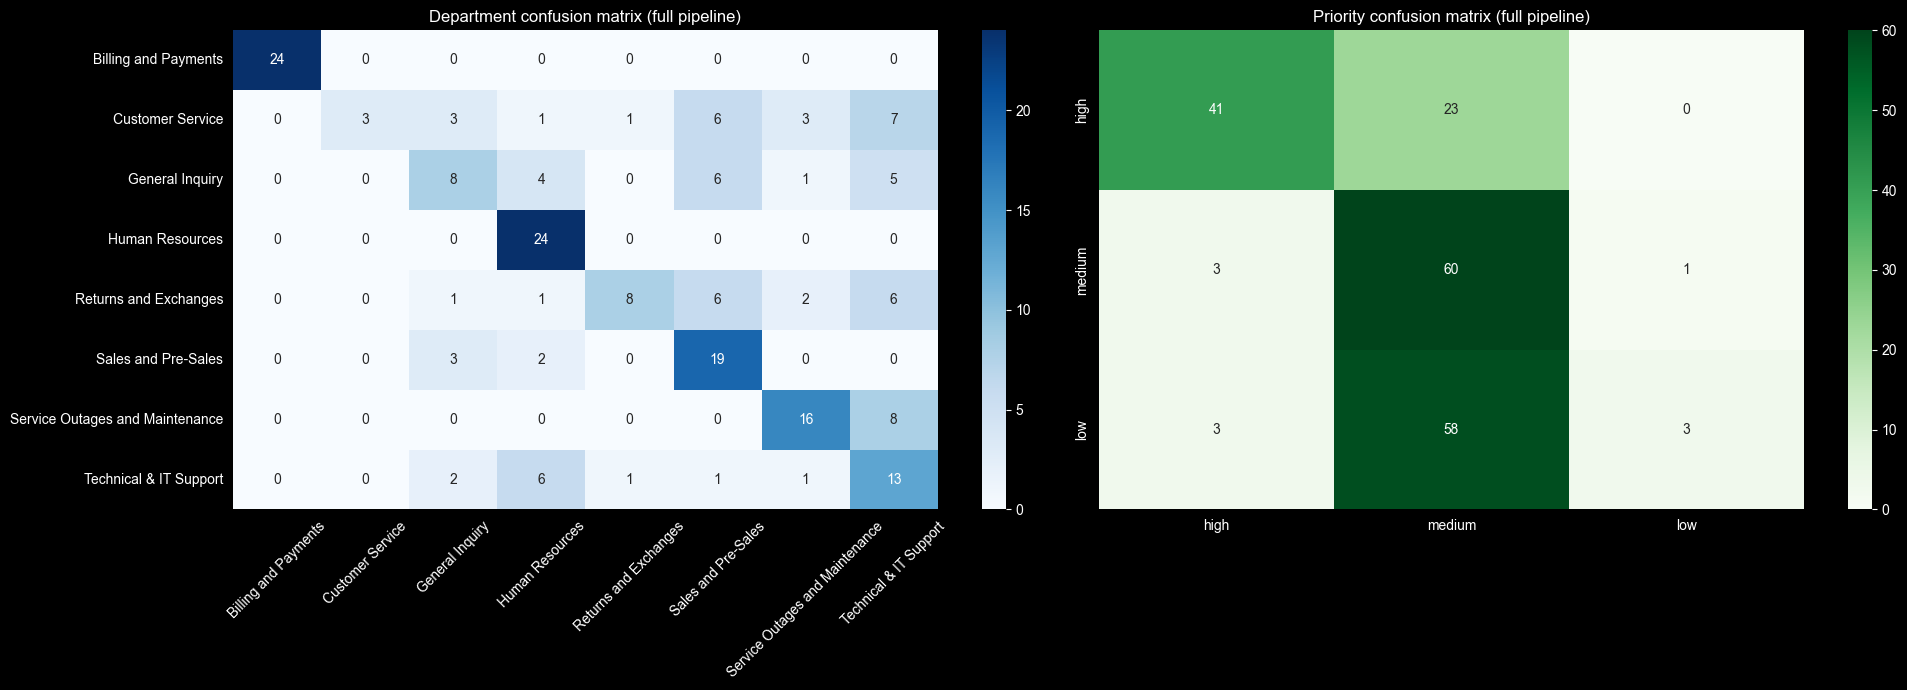

In [18]:
dept_labels = sorted(clean['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(confusion_matrix(clean['true_dept'], clean['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues', xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0])
axes[0].set_title('Department confusion matrix (full pipeline)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(clean['true_priority'], clean['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens', xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1])
axes[1].set_title('Priority confusion matrix (full pipeline)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pipeline_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

LATENCY METRICS
TTFT — Stage 1 rewrite (first blocking Groq call):
  Measured baseline : 2.048s

End-to-end latency (all stages):
  Mean   : 2.970s
  Median : 3.252s
  P90    : 4.399s

TPOT — Stage 3 output (reasoning paragraph):
  Mean   : 0.0221s/token
  Median : 0.0193s/token
  Avg reasoning tokens : 45
  Reference: human reading ~0.125-0.167s/token (6-8 tokens/s)

Fast path (no Stage 3 LLM): 22.9% of tickets


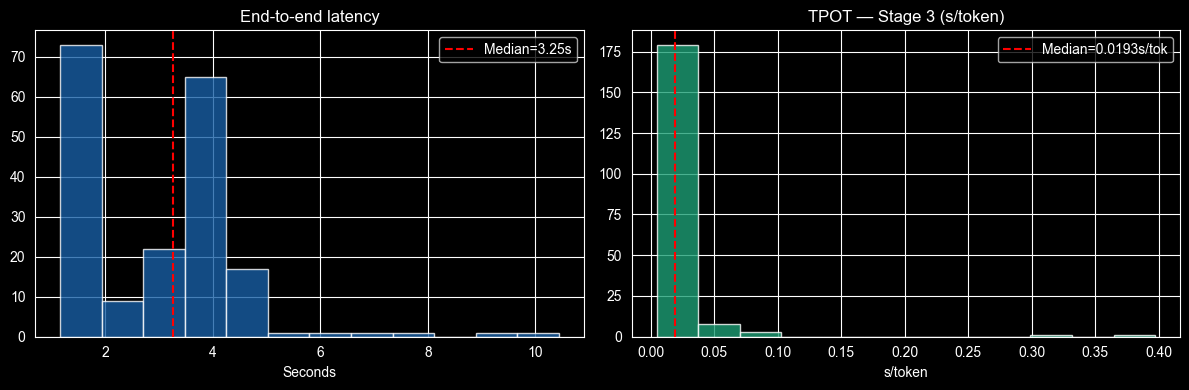

In [19]:
lat = clean[clean['t_total_s'].notna()]

print('=' * 60)
print('LATENCY METRICS')
print('=' * 60)
print(f'TTFT — Stage 1 rewrite (first blocking Groq call):')
print(f'  Measured baseline : {TTFT_BASELINE:.3f}s')
print()
print(f'End-to-end latency (all stages):')
print(f'  Mean   : {lat["t_total_s"].mean():.3f}s')
print(f'  Median : {lat["t_total_s"].median():.3f}s')
print(f'  P90    : {lat["t_total_s"].quantile(0.9):.3f}s')
print()
tpot_vals = lat[lat['tpot_s'].notna()]['tpot_s']
print(f'TPOT — Stage 3 output (reasoning paragraph):')
print(f'  Mean   : {tpot_vals.mean():.4f}s/token')
print(f'  Median : {tpot_vals.median():.4f}s/token')
print(f'  Avg reasoning tokens : {lat["reasoning_tokens"].mean():.0f}')
print(f'  Reference: human reading ~0.125-0.167s/token (6-8 tokens/s)')
print()
print(f'Fast path (no Stage 3 LLM): {clean["fast_path"].mean()*100:.1f}% of tickets')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lat['t_total_s'].hist(bins=12, ax=axes[0], color='#185FA5', alpha=0.8)
axes[0].axvline(lat['t_total_s'].median(), color='red', linestyle='--',
                label=f'Median={lat["t_total_s"].median():.2f}s')
axes[0].set_title('End-to-end latency'); axes[0].set_xlabel('Seconds'); axes[0].legend()

tpot_vals.hist(bins=12, ax=axes[1], color='#1D9E75', alpha=0.8)
axes[1].axvline(tpot_vals.median(), color='red', linestyle='--',
                label=f'Median={tpot_vals.median():.4f}s/tok')
axes[1].set_title('TPOT — Stage 3 (s/token)'); axes[1].set_xlabel('s/token'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'latency_distributions.png'),dpi=150,bbox_inches='tight')
plt.show()

In [22]:
# ── Section 4: AI-as-a-Judge ──────────────────────────────────────────────
#
# Why AI-as-a-judge:
#   Standard metrics (accuracy, F1) only tell you IF the answer is correct.
#   They cannot evaluate WHY — whether the reasoning cited real evidence,
#   whether Stage 1 rewrote faithfully, whether Stage 3 used transformer
#   confidence and RAG chunks correctly to justify its decision.
#   The judge evaluates these dimensions independently using custom rubrics.
#
#   Rubric 1 — Stage 1 rewrite quality
#   Rubric 2 — Stage 3 reasoning quality (slow path only)
#   Rubric 3 — Overall routing quality
#
# res.cleaned_text and res.reasoning come directly from RoutingResult —
# no extra Stage 1 call needed.

REWRITE_RUBRIC = """You are evaluating the quality of a customer support ticket rewriter.

ORIGINAL TICKET:
{original}

REWRITTEN TICKET:
{rewritten}

Score on a scale of 1 to 3:
1 = Meaning changed, key details lost, or department-specific vocabulary injected that was not in the original
2 = Meaning mostly preserved but rewrite is verbose, awkward, or adds minor assumptions not in original
3 = Meaning fully preserved, clean professional rewrite, no vocabulary injection, all key facts retained

Respond with ONLY a JSON object: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""


REASONING_RUBRIC = """You are evaluating whether an AI routing system justified its decision with real evidence.

TICKET:
{ticket}

PREDICTED DEPARTMENT: {pred_dept}
PREDICTED PRIORITY: {pred_priority}
REASONING PROVIDED:
{reasoning}

Score on a scale of 1 to 3:
1 = Reasoning is vague or fabricated — does not cite transformer confidence scores or RAG evidence
2 = Broadly correct but generic — mentions sources without specific values or concrete evidence
3 = Cites specific evidence: transformer confidence percentage, RAG chunk department, priority criteria — and explains clearly why they support this decision

Respond with ONLY a JSON object: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""


ROUTING_RUBRIC = """You are evaluating the overall quality of a support ticket routing decision.

TICKET:
{ticket}

PREDICTED DEPARTMENT: {pred_dept}  |  TRUE DEPARTMENT: {true_dept}
PREDICTED PRIORITY:   {pred_prio}  |  TRUE PRIORITY:   {true_prio}
REASONING: {reasoning}

Score on a scale of 1 to 3:
1 = Department or priority wrong, or reasoning does not support the decision made
2 = Department correct but priority questionable, or reasoning is weak and does not cite specific evidence
3 = Both department and priority correct, reasoning cites specific evidence from the ticket that justifies the decision

Respond with ONLY a JSON object: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""


from openai import OpenAI

openai_client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
JUDGE_MODEL = 'gpt-5.2'

def judge_call(prompt, retries=3):
    for attempt in range(retries):
        try:
            resp = openai_client.chat.completions.create(
                model=JUDGE_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=0.0,
            )
            raw = resp.choices[0].message.content.strip()
            m = re.search(r'\{.*?\}', raw, re.DOTALL)
            if m:
                return json.loads(m.group())
            return {'score': 0, 'reason': f'no JSON: {raw[:80]}'}
        except Exception as e:
            if 'rate_limit' in str(e).lower() and attempt < retries - 1:
                print(f'    Rate limit — waiting 20s (attempt {attempt+1})')
                time.sleep(20)
                continue
            return {'score': 0, 'reason': f'error: {e}'}
    return {'score': 0, 'reason': 'max retries exceeded'}
print('Judge rubrics and helper defined')

Judge rubrics and helper defined


In [23]:
# ── Run judge on pipeline_df sample ───────────────────────────────────────
# Uses 10 tickets — balanced across fast and slow path.
# Each ticket: 1 pipeline call + up to 3 judge calls = 4 Groq calls max.
# res.cleaned_text used throughout — no duplicate Stage 1 call.

if os.path.exists(JUDGE_RESULTS_PATH):
    _ej = pd.read_csv(JUDGE_RESULTS_PATH)
    if len(_ej) > 0 and 'rewrite_score' in _ej.columns:
        judge_df = _ej
        print(f'✓ Loaded cached judge results ({len(judge_df)} rows)')
    else:
        os.remove(JUDGE_RESULTS_PATH)

if not os.path.exists(JUDGE_RESULTS_PATH):
    # Pick 5 fast-path + 5 slow-path tickets for balanced coverage
    # Fall back to random sample if fast/slow split not available
    if 'fast_path' in results_df.columns:
        fast_pool = results_df[results_df['fast_path'] == 1]
        slow_pool = results_df[results_df['fast_path'] == 0]
        judge_sample = pd.concat([
            fast_pool.sample(min(5, len(fast_pool)), random_state=7),
            slow_pool.sample(min(5, len(slow_pool)), random_state=7),
        ]).reset_index(drop=True)
    else:
        judge_sample = pipeline_df.sample(min(10, len(pipeline_df)), random_state=99).reset_index(drop=True)

    print(f'Running AI judge on {len(judge_sample)} tickets...')
    jrecords = []

    for idx, row in tqdm(judge_sample.iterrows(), total=len(judge_sample)):
        raw_text  = row['raw_text'] if 'raw_text' in row else pipeline_df.loc[
            pipeline_df['queue'] == row['true_dept']
            ].iloc[0]['raw_text']

        try:
            # Single pipeline call — cleaned_text and reasoning in result
            res = route_ticket(
                raw_text,
                model, tokenizer, queue_encoder, priority_encoder, device,
                embedder,
                faiss_index, bm25, all_chunks, cross_encoder,
                priority_index, priority_chunks
            )
            time.sleep(1.0)

            is_slow_path = res.rag_used if hasattr(res, 'rag_used') else (res.reasoning != '')

            # Rubric 1: Stage 1 rewrite quality
            r1 = judge_call(REWRITE_RUBRIC.format(
                original=raw_text[:500],
                rewritten=res.cleaned_text[:500]
            ))
            time.sleep(1.0)

            # Rubric 2: Stage 3 reasoning quality — only meaningful on slow path
            # Fast path: transformer was confident, LLM reasoning not invoked
            if is_slow_path:
                r2 = judge_call(REASONING_RUBRIC.format(
                    ticket=res.cleaned_text[:400],
                    pred_dept=res.department,
                    pred_priority=res.priority,
                    reasoning=res.reasoning[:500]
                ))
                time.sleep(1.0)
            else:
                r2 = {
                    'score' : None,
                    'reason': 'fast path — transformer confident, Stage 3 LLM not invoked'
                }

            # Rubric 3: Overall routing quality (all tickets)
            r3 = judge_call(ROUTING_RUBRIC.format(
                ticket=res.cleaned_text[:400],
                pred_dept=res.department,  true_dept=row['true_dept'],
                pred_prio=res.priority,    true_prio=row['true_priority'],
                reasoning=res.reasoning[:500]
            ))
            time.sleep(1.0)

            jrecords.append({
                'true_dept'        : row['true_dept'],
                'true_priority'    : row['true_priority'],
                'pred_dept'        : res.department,
                'pred_priority'    : res.priority,
                'dept_correct'     : int(res.department == row['true_dept']),
                'prio_correct'     : int(res.priority   == row['true_priority']),
                'fast_path'        : int(not is_slow_path),
                'rewrite_score'    : r1.get('score'),
                'rewrite_reason'   : r1.get('reason'),
                'reasoning_score'  : r2.get('score'),
                'reasoning_reason' : r2.get('reason'),
                'routing_score'    : r3.get('score'),
                'routing_reason'   : r3.get('reason'),
            })

        except Exception as e:
            print(f'✗ Row {idx}: {e}')

        time.sleep(1.5)

    judge_df = pd.DataFrame(jrecords)
    judge_df.to_csv(JUDGE_RESULTS_PATH, index=False)
    print(f'✓ Judge complete — {len(judge_df)} tickets saved')

if 'judge_df' not in dir():
    judge_df = pd.read_csv(JUDGE_RESULTS_PATH)

Running AI judge on 10 tickets...


  0%|          | 0/10 [00:00<?, ?it/s]

17:06:09  INFO      [router]  ============================================================
17:06:09  INFO      [router]  NEW TICKET (312 chars): 'The client was billed incorrectly on the most recent invoice, likely due to an e'
17:06:09  INFO      [router]  ============================================================
17:06:09  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (312 chars)
17:06:09  DEBUG     [stage1.rewriter]  Raw input: 'The client was billed incorrectly on the most recent invoice, likely due to an error in the billing system. After examin'
17:06:11  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Incorrect billing on recent invoice, refund requested'
17:06:11  DEBUG     [stage1.rewriter]  Urgency signals : ['expedited response']
17:06:11  DEBUG     [stage1.rewriter]  Tech keywords   : ['billing system', 'invoice', 'statements']
17:06:11  DEBUG     [stage1.rewriter]  Explanation     : The likely department is billing.
17:06:11  DEBUG     [stage1.rewriter]  

 10%|█         | 1/10 [00:11<01:44, 11.64s/it]

17:06:21  INFO      [router]  ============================================================
17:06:21  INFO      [router]  NEW TICKET (573 chars): 'We have discovered a severe disruption affecting the EMR/PACS connections, which'
17:06:21  INFO      [router]  ============================================================
17:06:21  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (573 chars)
17:06:21  DEBUG     [stage1.rewriter]  Raw input: 'We have discovered a severe disruption affecting the EMR/PACS connections, which seems to be caused by a network failure'
17:06:23  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Severe disruption in EMR/PACS connections'
17:06:23  DEBUG     [stage1.rewriter]  Urgency signals : ['severe disruption', 'urgent assistance', 'immediate vulnerabilities', 'prompt response']
17:06:23  DEBUG     [stage1.rewriter]  Tech keywords   : ['EMR', 'PACS', 'network failure', 'security compromise', 'SOC', 'DevSecOps', 'vulnerabilities']
17:06:23  DEBUG     [

...

17:07:52  INFO      [router]  ============================================================
17:07:52  INFO      [router]  NEW TICKET (369 chars): 'Given that the healthcare sector is a primary target for cyber-attacks, it is cr'
17:07:52  INFO      [router]  ============================================================
17:07:52  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (369 chars)
17:07:52  DEBUG     [stage1.rewriter]  Raw input: 'Given that the healthcare sector is a primary target for cyber-attacks, it is crucial to implement proactive measures to'
17:07:54  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Request to enhance cybersecurity measures in healthcare'
17:07:54  DEBUG     [stage1.rewriter]  Urgency signals : ['crucial', 'prevent potential security breaches']
17:07:54  DEBUG     [stage1.rewriter]  Tech keywords   : ['cyber-attacks', 'multi-factor authentication', 'software updates', 'patching', 'encryption']
17:07:54  DEBUG     [stage1.rewriter]  Explanatio

 90%|█████████ | 9/10 [01:57<00:14, 14.01s/it]

17:08:07  INFO      [router]  ============================================================
17:08:07  INFO      [router]  NEW TICKET (341 chars): 'I am requesting an enhancement in our data analytics capabilities. My aim is to '
17:08:07  INFO      [router]  ============================================================
17:08:07  INFO      [stage1.rewriter]  Stage 1 — rewriting ticket (341 chars)
17:08:07  DEBUG     [stage1.rewriter]  Raw input: 'I am requesting an enhancement in our data analytics capabilities. My aim is to optimize investment strategies using app'
17:08:08  INFO      [stage1.rewriter]  Stage 1 done — subject: 'Request for data analytics enhancement tools'
17:08:08  DEBUG     [stage1.rewriter]  Urgency signals : []
17:08:08  DEBUG     [stage1.rewriter]  Tech keywords   : ['data analytics', 'investment strategies', 'software', 'hardware', 'data-driven decision-making']
17:08:08  DEBUG     [stage1.rewriter]  Explanation     : The likely department is responsible for data a

100%|██████████| 10/10 [02:09<00:00, 12.91s/it]

✓ Judge complete — 10 tickets saved


AI-AS-A-JUDGE RESULTS  (1=poor  2=acceptable  3=excellent)
Stage 1 rewrite quality  : mean=3.00  dist={3: 10}
Stage 3 reasoning quality: mean=2.20  dist={1: 2, 2: 4, 3: 4}
Overall routing quality  : mean=2.20  dist={1: 2, 2: 4, 3: 4}

Fast path (transformer confident, no LLM): 0 tickets
Slow path (RAG + LLM invoked)            : 10 tickets
(Reasoning rubric only scored on slow path — LLM not invoked on fast path)

Sample judge reasoning:

── Rewrite quality ──
  Score 3: The rewritten ticket is identical to the original, preserving all meaning and key details without adding assumptions or new terminology.

── Reasoning quality ──
  Score 3: The reasoning cites specific transformer confidence scores (99.6% for Billing and Payments, 81.4% for medium priority) and explicitly states they exceeded thresholds to justify the fast-path decision.
  Score 2: It cites specific transformer confidence percentages and threshold logic, but provides no RAG evidence or concrete ticket-based priority cr

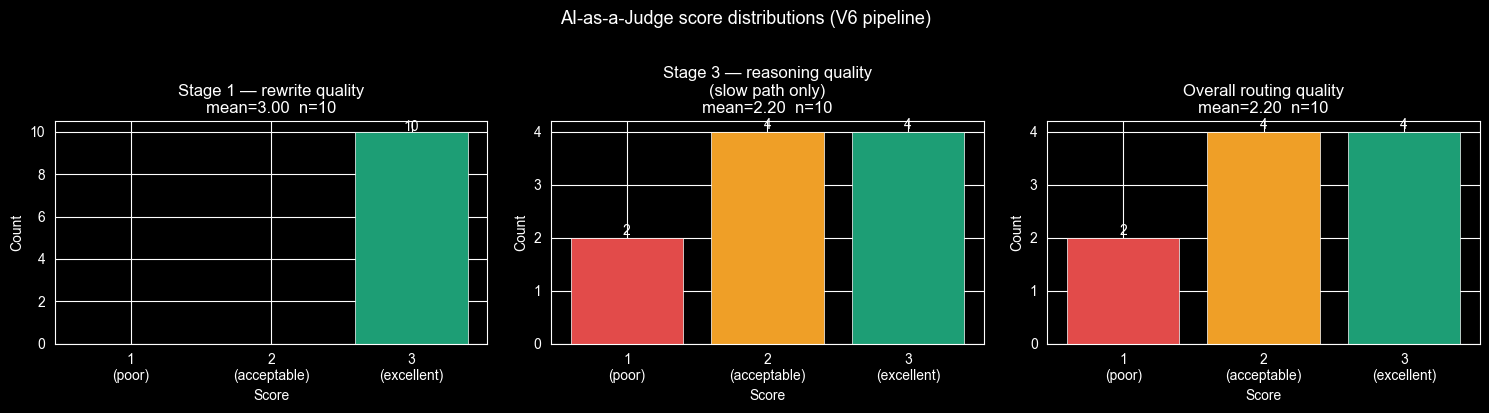

✓ Saved judge_scores.png


In [24]:
# ── Judge results summary + plots ─────────────────────────────────────────
numeric = judge_df.copy()
for col in ['rewrite_score', 'reasoning_score', 'routing_score']:
    numeric[col] = pd.to_numeric(numeric[col], errors='coerce')

print('=' * 60)
print('AI-AS-A-JUDGE RESULTS  (1=poor  2=acceptable  3=excellent)')
print('=' * 60)
for col, label in [
    ('rewrite_score',   'Stage 1 rewrite quality  '),
    ('reasoning_score', 'Stage 3 reasoning quality'),
    ('routing_score',   'Overall routing quality  '),
]:
    vals = numeric[col].dropna()
    if len(vals):
        dist = vals.value_counts().sort_index().to_dict()
        print(f'{label}: mean={vals.mean():.2f}  dist={dist}')

fast_n = (judge_df['fast_path'] == 1).sum()
slow_n = (judge_df['fast_path'] == 0).sum()
print(f'\nFast path (transformer confident, no LLM): {fast_n} tickets')
print(f'Slow path (RAG + LLM invoked)            : {slow_n} tickets')
print(f'(Reasoning rubric only scored on slow path — LLM not invoked on fast path)')

# Sample reasoning per score level
print('\nSample judge reasoning:')
for col, rcol, label in [
    ('rewrite_score',   'rewrite_reason',   'Rewrite quality'),
    ('reasoning_score', 'reasoning_reason', 'Reasoning quality'),
    ('routing_score',   'routing_reason',   'Routing quality'),
]:
    print(f'\n── {label} ──')
    for _, r in numeric[[col, rcol]].dropna(subset=[col]).drop_duplicates(col).iterrows():
        score = r[col]
        reason = r[rcol]
        if pd.notna(score) and pd.notna(reason):
            print(f'  Score {int(score)}: {reason}')

# Score distribution bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in [
    (axes[0], 'rewrite_score',   'Stage 1 — rewrite quality'),
    (axes[1], 'reasoning_score', 'Stage 3 — reasoning quality\n(slow path only)'),
    (axes[2], 'routing_score',   'Overall routing quality'),
]:
    vals = numeric[col].dropna()
    if len(vals):
        counts = vals.value_counts().sort_index().reindex([1, 2, 3], fill_value=0)
        bars = ax.bar([1, 2, 3], counts.values, color=['#E24B4A', '#EF9F27', '#1D9E75'],
                      edgecolor='white', linewidth=0.5)
        ax.set_title(f'{title}\nmean={vals.mean():.2f}  n={int(len(vals))}')
        ax.set_xlabel('Score'); ax.set_ylabel('Count')
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['1\n(poor)', '2\n(acceptable)', '3\n(excellent)'])
        for bar, count in zip(bars, counts.values):
            if count > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                        str(count), ha='center', fontsize=10)

plt.suptitle('AI-as-a-Judge score distributions (V6 pipeline)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'judge_scores.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved judge_scores.png')

In [26]:
# ── Final summary ──────────────────────────────────────────────────────────
print('=' * 65)
print('EVALUATION SUMMARY — V6 pipeline')
print('=' * 65)

print('\n── Sec 1: Transformer standalone (Stage 2a) ──')
print(f'  Dept  Accuracy={dept_acc*100:.1f}%  F1={dept_f1*100:.1f}%  ECE={dept_ece:.4f}')
print(f'  Prio  Accuracy={prio_acc*100:.1f}%  F1={prio_f1*100:.1f}%  ECE={prio_ece:.4f}')

print('\n── Sec 2: RAG retrieval (Stage 2b) ──')
print(f'  Dept  Recall@1={rag_df["recall_at_1"].mean()*100:.1f}%  '
      f'Recall@4={rag_df["recall_at_4"].mean()*100:.1f}%  MRR={rag_df["mrr"].mean():.3f}')
print(f'  Prio  Section accuracy={rag_df["prio_correct"].mean()*100:.1f}%  (random baseline 33.3%)')

print('\n── Sec 3: Full pipeline ──')
if 'clean' in dir() and len(clean):
    print(f'  Dept  Accuracy={clean["dept_correct"].mean()*100:.1f}%')
    print(f'  Prio  Accuracy={clean["prio_correct"].mean()*100:.1f}%')
    print(f'  Fast path rate={clean["fast_path"].mean()*100:.1f}% of tickets')
    # if 'delta' in dir():
    #     print(f'  LLM override improvement={delta:+.1f}pp dept accuracy')
    _lat = clean[clean['t_total_s'].notna()]
    print(f'  TTFT={TTFT_BASELINE:.3f}s  E2E median={_lat["t_total_s"].median():.3f}s  '
          f'P90={_lat["t_total_s"].quantile(0.9):.3f}s')
    _tp = _lat[_lat['tpot_s'].notna()]['tpot_s']
    if len(_tp):
        print(f'  TPOT median={_tp.median():.4f}s/token (Stage 3, slow path)')

print('\n── Sec 4: AI-as-a-judge ──')
if 'numeric' in dir() and len(numeric):
    for col, label in [
        ('rewrite_score',   'Stage 1 rewrite   (1-3)'),
        ('reasoning_score', 'Stage 3 reasoning (1-3)'),
        ('routing_score',   'Overall routing   (1-3)'),
    ]:
        v = numeric[col].dropna()
        if len(v): print(f'  {label}: {v.mean():.2f}')

print(f'\nOutputs saved to: {OUT_DIR}')

EVALUATION SUMMARY — V6 pipeline

── Sec 1: Transformer standalone (Stage 2a) ──
  Dept  Accuracy=75.1%  F1=75.4%  ECE=0.0388
  Prio  Accuracy=90.1%  F1=77.1%  ECE=0.0727

── Sec 2: RAG retrieval (Stage 2b) ──
  Dept  Recall@1=39.9%  Recall@4=62.7%  MRR=0.491
  Prio  Section accuracy=49.4%  (random baseline 33.3%)

── Sec 3: Full pipeline ──
  Dept  Accuracy=65.0%
  Prio  Accuracy=88.8%
  Fast path rate=61.3% of tickets
  TTFT=1.853s  E2E median=2.095s  P90=4.092s
  TPOT median=0.0089s/token (Stage 3, slow path)

── Sec 4: AI-as-a-judge ──
  Stage 1 rewrite   (1-3): 3.00
  Stage 3 reasoning (1-3): 2.20
  Overall routing   (1-3): 2.20

Outputs saved to: /Users/avani/IdeaProjects/customer-support-management/outputs/evaluation
